### Use a GP to predict activity

It's hard to not overfit the MLP. Tense. And not theoretically justified. But a GP... could have the right number of parameters. Let's try that. Plus there's literature evidence of using a GP to predict the residual off of naturalness.

The strategy: use an ExactGP from gpytorch. It's not a perfect model - that requires that the likelihood function be gaussian, but our likelihoods are Bernoulli (Bradley Terry), and taken over tuples... so we're abusing the normal solver. More to the point, the variances of the output model will be poorly calibrated. But the means will be accurate, and the covariances will be reflective, if not perfect. And we can use all of the gpytorch machinery for free, including their DKL guides.

In [1]:
# Exact DKL on Proteingym with an MLP(…→6) + GP   |  author: Jacob 2025-04-26
# --------------------------------------------------------------------------------------------------
import torch, math, itertools, tqdm, gpytorch
from torch import nn
from torch.nn import functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging

from folde.data import get_available_proteingym_datasets, get_proteingym_dataset

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger()



In [63]:
# ---------------------------------------------------------------------------
#  Single-DMS BatchConstructor – now with PCA features
# ---------------------------------------------------------------------------
from sklearn.decomposition import PCA            # ← new import (one-liner)

class BatchConstructor:
    """
    [...]
    pca_train / pca_val : (N_train, 20) / (N_val, 20) torch.float32 on device
                          – first 20 principal components of the embeddings
    """

    def __init__(
        self,
        dms_id:     str,
        natural_df,
        embed_df,
        activity_df,
        N_train:    int,
        N_val:      int,
        batch_size: int,
        device:     torch.device,
    ):
        logging.info(f"Constructing BatchConstructor for {dms_id}.")
        self.device, self.batch_size = device, batch_size
        self.rng = np.random.default_rng()

        # ---------- slice the requested DMS --------------------------------
        assert embed_df.index.equals(natural_df.index)
        assert embed_df.index.equals(activity_df.index)
        if embed_df.shape[0] < N_train + N_val:
            raise ValueError(f"Contains < N_train+N_val sequences.")

        seq_ids = embed_df.index
        emb_all = np.stack(embed_df.loc[seq_ids, "embedding"]).astype(np.float32)
        nat_all = np.log(natural_df.loc[seq_ids, 'wt_marginal'].astype(np.float32).to_numpy())
        act_all = activity_df.loc[seq_ids, 'DMS_score'].astype(np.float32).to_numpy()

        # ---------- fit PCA on *all* embeddings for this DMS ---------------
        pca = PCA(n_components=20, whiten=False, svd_solver='auto').fit(emb_all)
        pcs_all = pca.transform(emb_all).astype(np.float32)      # shape (N_total, 20)

        # ---------- sort by activity high→low once -------------------------
        order   = act_all.argsort()[::-1]
        emb_all, nat_all, act_all, pcs_all = \
            emb_all[order], nat_all[order], act_all[order], pcs_all[order]
        N_total = len(act_all)

        # ---------- validation split ---------------------------------------
        self.val_idx = self.rng.choice(range(N_total), N_val, replace=False)
        remaining = np.setdiff1d(np.arange(N_total), self.val_idx, assume_unique=True)

        # ---------- build training split (50 % / 50 %) ---------------------
        n_top      = max(1, int(np.ceil(0.10 * N_total)))
        top_pool   = np.intersect1d(np.arange(n_top), remaining)
        rest_pool  = np.intersect1d(np.arange(n_top, N_total), remaining)

        k_top = N_train // 2
        k_bot = N_train - k_top
        if k_top > len(top_pool):
            logging.warning(f'k_top > len(top_pool): {k_top} > {len(top_pool)} for {dms_id}. Using all of top_pool.')
            k_top = len(top_pool)
            k_bot = N_train - k_top

        train_idx_top  = self.rng.choice(top_pool,  k_top, replace=False)
        train_idx_bot  = self.rng.choice(rest_pool, k_bot, replace=False)
        self.train_idx = np.concatenate([train_idx_top, train_idx_bot])

        # ---------- tensors on device --------------------------------------
        self.emb_train = torch.tensor(emb_all[self.train_idx], dtype=torch.float32, device=device)
        self.nat_train = torch.tensor(nat_all[self.train_idx], dtype=torch.float32, device=device)
        self.act_train = act_all[self.train_idx]                                   # numpy (labels)

        self.emb_val  = torch.tensor(emb_all[self.val_idx],  dtype=torch.float32, device=device)
        self.nat_val  = torch.tensor(nat_all[self.val_idx],  dtype=torch.float32, device=device)
        self.act_val  = torch.tensor(act_all[self.val_idx],  dtype=torch.float32, device=device)

        # ------------ NEW: PCA tensors -------------------------------------
        self.pca_train = torch.tensor(pcs_all[self.train_idx], dtype=torch.float32, device=device)
        self.pca_val   = torch.tensor(pcs_all[self.val_idx],  dtype=torch.float32, device=device)

        # ---------- enumerate *all* ordered pairs (i,j), i≠j ---------------
        I, J = np.meshgrid(np.arange(N_train), np.arange(N_train), indexing="ij")
        all_pairs = np.stack([I.ravel(), J.ravel()], axis=1)
        mask      = all_pairs[:, 0] != all_pairs[:, 1]          # drop self-pairs
        self.pairs_full = torch.tensor(all_pairs[mask], dtype=torch.long, device=device)

        # labels: 1. if act_i > act_j else 0.
        ai = self.act_train[self.pairs_full[:, 0].cpu().numpy()]
        aj = self.act_train[self.pairs_full[:, 1].cpu().numpy()]
        self.labels_full = torch.tensor((ai > aj).astype(np.float32), device=device)

        self._cursor = 0        # iterator state

    # --------------------------------------------------------------------- #
    def __iter__(self):
        perm = torch.randperm(len(self.pairs_full))
        self.pairs_full  = self.pairs_full[perm]
        self.labels_full = self.labels_full[perm]
        self._cursor = 0
        return self

    def __next__(self):
        if self._cursor >= len(self.pairs_full):
            raise StopIteration

        end          = min(self._cursor + self.batch_size, len(self.pairs_full))
        pairs_batch  = self.pairs_full [self._cursor:end]
        labels_batch = self.labels_full[self._cursor:end]
        self._cursor = end

        return self.emb_train, self.nat_train, self.pca_train, pairs_batch, labels_batch

    # --------------------------------------------------------------------- #
    @property
    def validation_tensors(self):
        """Return (emb_val, nat_val, act_val, pca_val) ready for metrics."""
        return self.emb_val, self.nat_val, self.act_val, self.pca_val

old_ids = get_available_proteingym_datasets('300m', '600m').DMS_id
new_ids = get_available_proteingym_datasets('300m_extras', '600m').DMS_id
defunct_ids = [ii for ii in old_ids if ii not in new_ids]

batch_constructors = [
    BatchConstructor(dms_id, *get_proteingym_dataset(
        dms_id,
        "300m",
        "600m",
    ), 300, 1000, 10000, 'cpu')
    for dms_id in defunct_ids
]

2025-05-01 03:48:54,721 - folde.data - INFO - Loaded metadata for 217 DMS datasets
2025-05-01 03:48:54,753 - folde.data - INFO - Found 11 datasets with embedding model '300m' and naturalness model '600m'
2025-05-01 03:48:54,761 - folde.data - INFO - Loaded metadata for 217 DMS datasets
2025-05-01 03:48:54,784 - folde.data - INFO - Found 9 datasets with embedding model '300m_extras' and naturalness model '600m'
2025-05-01 03:48:55,188 - folde.data - INFO - Loaded activity data for A0A140D2T1_ZIKV_Sourisseau_2019 with 9576 rows
2025-05-01 03:48:57,229 - folde.data - INFO - Loaded embeddings for A0A140D2T1_ZIKV_Sourisseau_2019 with 9577 rows
2025-05-01 03:48:57,256 - folde.data - INFO - Loaded naturalness scores for A0A140D2T1_ZIKV_Sourisseau_2019 with 16632 rows
2025-05-01 03:49:00,335 - root - INFO - Constructing BatchConstructor for A0A140D2T1_ZIKV_Sourisseau_2019.
2025-05-01 03:49:03,279 - folde.data - INFO - Loaded activity data for A0A2Z5U3Z0_9INFA_Doud_2016 with 10715 rows
2025-05-

In [64]:
from itertools import cycle

def round_robin(models, batch_constructors):
    """
    Iterate over multiple iterables in round-robin fashion until all are exhausted.
    
    Args:
        *iterables: Any number of iterables
        
    Yields:
        Elements from the iterables in round-robin order
    """
    iterators = [(model, iter(it)) for model, it in zip(models, batch_constructors)]
    pending = len(batch_constructors)
    nexts = cycle(iterators)
    
    while pending:
        try:
            for model, iterator in nexts:
                yield model, next(iterator)
        except StopIteration:
            # Remove exhausted iterator
            pending -= 1
            nexts = cycle((model, it) for model, it in iterators if it is not iterator)


In [77]:
##############################
# 0.  Imports
##############################
import itertools
import torch
import torch.nn as nn
import torch.nn.functional as F
import gpytorch
from tqdm import trange
import time
import scipy
from typing import Any, Callable, Dict, List, Optional, Tuple, Union

SMOKE_TEST = False
USE_BT_LIKELIHOOD = True
NUM_GP_FEATURES = 20
USE_BT_LOSS = False          # <— flip to False for ordinary regression
USE_PCA = True

if SMOKE_TEST:
    EPOCHS = 2
else:
    EPOCHS = 30

# -----  to-torch  -----
device = "cuda" if torch.cuda.is_available() else "cpu"


# ---------------------------------------------------------------------------
# 2. Build MLP feature extractor  (d_emb → 256 → 64 → 6) ---------------------
# ---------------------------------------------------------------------------
class Extractor(nn.Sequential):
    def __init__(
        self,
        d_in: int,
        d_out: int,
        hidden_dims: List[int] = [128, 64, 32],
        dropout: float = 0.2,
        activation: nn.Module = nn.ReLU(),
    ):
        # Build MLP layers
        layers = []
        prev_dim = d_in


        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim, bias=False))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(activation)
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        # Final layer to scalar preference score
        layers.append(nn.Linear(prev_dim, d_out, bias=False))  # no bias)

        super().__init__(*layers)

    def forward(self, x):
        return super().forward(x)


# ---------------------------
# 5. Assemble ExactGP
# ---------------------------
class ExactDKL(gpytorch.models.ExactGP):
    def __init__(self, feature_extractor, X, y_train, likelihood, num_gp_features: int):
        # dummy y required by gpytorch.ExactGP – not used
        super().__init__(X, y_train, likelihood)
        self.feature_extractor = feature_extractor
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=num_gp_features))
        self.beta = nn.Parameter(torch.tensor(1.0))

    def forward(self, x):
        if USE_PCA:
            z = x
            mean = self.mean_module(z)
            cov = self.covar_module(z)
        else:
            z = self.feature_extractor(x)  # latent features
            mean = self.mean_module(z[:, :-1]).view(-1) + z[:, -1]# + self.beta * self.nat_vec[idx].view(-1)
            # mean = self.mean_module(z[:, :-1]) + self.beta * self.nat_vec[idx].view(-1)
            cov = self.covar_module(z[:, :-1])
        return gpytorch.distributions.MultivariateNormal(mean, cov)
    


def validate(feature_extractor, models, likelihoods, bcs):
    feature_extractor.eval()
    for model, likelihood in zip(models, likelihoods):
        model.eval()
        likelihood.eval()
    try:
        train_spearmans = []
        val_spearmans = []
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            for model, bc in zip(models, bcs):
                if USE_PCA:
                    train_X_all = bc.pca_train
                    val_X_all = bc.pca_val
                else:
                    train_X_all = torch.cat([bc.emb_train, bc.nat_train.unsqueeze(-1)], dim=-1)
                    val_X_all = torch.cat([bc.emb_val, bc.nat_val.unsqueeze(-1)], dim=-1)
                train_util = model(train_X_all).mean  # Exact posterior (N-dim MVN)
                train_spearmans.append(scipy.stats.spearmanr(bc.act_train, train_util.cpu().numpy())[0])

                val_util = model(val_X_all).mean  # Exact posterior (N-dim MVN)
                val_spearmans.append(scipy.stats.spearmanr(bc.act_val, val_util.cpu().numpy())[0])

        return train_spearmans, val_spearmans
    finally:
        feature_extractor.train()
        for model, likelihood in zip(models, likelihoods):
            model.train()
            likelihood.train()


# ---------------------------
# 6. Likelihood
# ---------------------------

d_in = batch_constructors[0].emb_train.shape[1]
print(f'Embeddings have dimension {d_in}')
feature_extractor = Extractor(d_in=d_in + 1, d_out=NUM_GP_FEATURES + 1)
likelihoods, mlls, models = [], [], []
for bc in batch_constructors:
    if USE_PCA:
        X_all = bc.pca_train
    else:
        X_all = torch.cat([bc.emb_train, bc.nat_train.unsqueeze(-1)], dim=-1)

    y_raw = torch.tensor(bc.act_train, device=device)

    # — likelihood —
    lk = gpytorch.likelihoods.GaussianLikelihood().to(device)
    lk.noise_covar.initialize(noise=1e-3)
    likelihoods.append(lk)

    # — GP —
    gp = ExactDKL(feature_extractor, X_all, y_raw, lk, NUM_GP_FEATURES).to(device)
    models.append(gp)

    # — MLL (needed only when USE_BT_LOSS = False *and* you choose
    #         to train with −mll instead of MSE) —
    mlls.append(gpytorch.mlls.ExactMarginalLogLikelihood(lk, gp))
# ---------------------------------------------------------------------------
# 7. Training loop -----------------------------------------------------------
# ---------------------------------------------------------------------------
feature_extractor.train()
for model, likelihood in zip(models, likelihoods):
    model.train()
    likelihood.train()

# # one line: grab **every** learnable parameter the model owns
# opt = torch.optim.Adam(
#         list(model.parameters())                      # DKL + β + constant mean
#         + ([] if isinstance(likelihood, gpytorch.likelihoods.GaussianLikelihood)
#             else list(likelihood.parameters())),
#         lr=1e-3
# )
param_groups = [{'params': feature_extractor.parameters()}] \
             + [{'params': lk.parameters()}       for lk in likelihoods] \
             + [{'params': m.mean_module.parameters()} for m in models] \
             + [{'params': m.covar_module.parameters()} for m in models]

optimizer = torch.optim.Adam(param_groups, lr=1e-2)
val_spearman_list = [0.0]
train_spearman_list = [0.0]

with gpytorch.settings.max_cholesky_size(2000):#, gpytorch.settings.fast_pred_var():
    pbar = tqdm.trange(EPOCHS, desc="⏳ training", position=0, leave=True)
    start_time = time.time()
    for epoch in pbar:
        total_loss = 0.0

        if USE_BT_LOSS:
            for model, (emb, nat, pcas, pairs, labels) in round_robin(models, batch_constructors):
                optimizer.zero_grad()

                if USE_PCA:
                    X_all = pcas
                else:
                    X_all = torch.cat([emb, nat.unsqueeze(-1)], dim=-1)
                f_dist = model(X_all)  # Exact posterior (N-dim MVN)
                util = f_dist.mean  # (N,)  

                fi = util[pairs[:, 0]]
                fj = util[pairs[:, 1]]
                logits = fi - fj
                loss   = F.binary_cross_entropy_with_logits(logits, labels)
                loss   = loss #+ 1e-3 * util.pow(2).mean()      # optional L2-utility reg

                loss.backward()                                # accumulates gradients
                optimizer.step()

                total_loss += loss.item()# / (len(pairs) / BATCH_SIZE)
        else:
            optimizer.zero_grad()
            cum_loss = None
            for model, likelihood, mll, bc in zip(models, likelihoods, mlls, batch_constructors):

                if USE_PCA:
                    X_all = bc.pca_train
                else:
                    X_all = torch.cat([bc.emb_train, bc.nat_train.unsqueeze(-1)], dim=-1)
                out = model(X_all)                      # f(X)  ~  MVN
                # mean = out.mean                    
                y = torch.tensor(bc.act_train, device=device)

                loss = -mll(out, y)       # exact marginal log-likelihood
                if cum_loss is None:
                    cum_loss = loss
                else:
                    cum_loss += loss
            cum_loss.backward()                                # accumulates gradients
            optimizer.step()

            total_loss += cum_loss.item() / len(models)


        
        if epoch % 1 == 0:
            train_spearmans, val_spearmans = validate(feature_extractor, models, likelihoods, batch_constructors)
            train_spearman = sum([s for s in train_spearmans]) / len(train_spearmans)
            val_spearman = sum([s for s in val_spearmans]) / len(val_spearmans)
            train_spearman_list.append(train_spearman)
            val_spearman_list.append(val_spearman)


        # --- diagnostics -------------------------------------------------
        pbar.set_postfix(
            epoch=epoch, Loss=f"{total_loss:.4f}", elapsed=f"{(time.time()-start_time):.1f}s", ValSpearman=f"{val_spearman_list[-1]:.4f}", trainSpearman=f"{train_spearman_list[-1]:.4f}"
        )

# ---------------------------------------------------------------------------
# 8. Done – the trained model is `model`, ready for evaluation --------------
# ---------------------------------------------------------------------------

Embeddings have dimension 960


⏳ training: 100%|██████████| 30/30 [00:07<00:00,  4.27it/s, Loss=272.0222, ValSpearman=0.4089, elapsed=7.0s, epoch=29, trainSpearman=0.4708]


<Axes: >

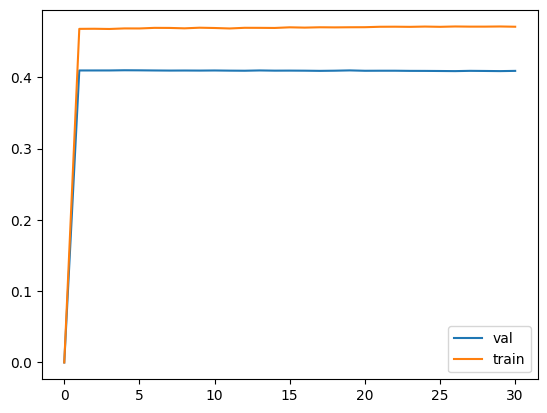

In [78]:
import seaborn as sns
sns.lineplot(x=range(len(val_spearman_list)), y=val_spearman_list, label="val")
sns.lineplot(x=range(len(train_spearman_list)), y=train_spearman_list, label="train")

In [57]:
X_all = torch.cat([batch_constructors[1].emb_train, batch_constructors[1].nat_train.unsqueeze(-1)], dim=-1)


with torch.no_grad():
    z = feature_extractor(X_all).cpu().numpy()
print(z.mean(axis=0)[:5], z.std(axis=0)[:5])

[-0.41784954  0.27541345 -0.06785959  0.04673989 -0.23078321] [0.31773934 0.29342532 0.3534277  0.26565123 0.34046295]


In [81]:
feature_extractor.eval()
likelihood.eval()
for model in models:
    model.eval()

train_util_list = []
val_util_list = []
for model, bc in zip(models, batch_constructors):
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        # print(f"emb_train dtype: {bc.emb_train.dtype}")
        # print(f"nat_train dtype: {bc.nat_train.dtype}")
        # print(f"model parameters dtype: {next(model.parameters()).dtype}")
        # print(f"act train dtype: {bc.act_train.dtype}")
        if USE_PCA:
            train_X_all = bc.pca_train
            val_X_all = bc.pca_val
        else:
            train_X_all = torch.cat([bc.emb_train, bc.nat_train.unsqueeze(-1)], dim=-1)
            val_X_all = torch.cat([bc.emb_val, bc.nat_val.unsqueeze(-1)], dim=-1)
        print(train_X_all.shape)
        train_f_dist = model(train_X_all)  # Exact posterior (N-dim MVN)
        train_util = train_f_dist.mean  # (N,)  
        train_util_list.append(train_util)

        val_f_dist = model(val_X_all)  # Exact posterior (N-dim MVN)
        val_util = val_f_dist.mean  # (N,)  
        val_util_list.append(val_util)


torch.Size([300, 20])
torch.Size([300, 20])
torch.Size([300, 20])
torch.Size([300, 20])
torch.Size([300, 20])
torch.Size([300, 20])
torch.Size([300, 20])
torch.Size([300, 20])
torch.Size([300, 20])
torch.Size([300, 20])
torch.Size([300, 20])


/opt/conda/envs/worker/lib/python3.12/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


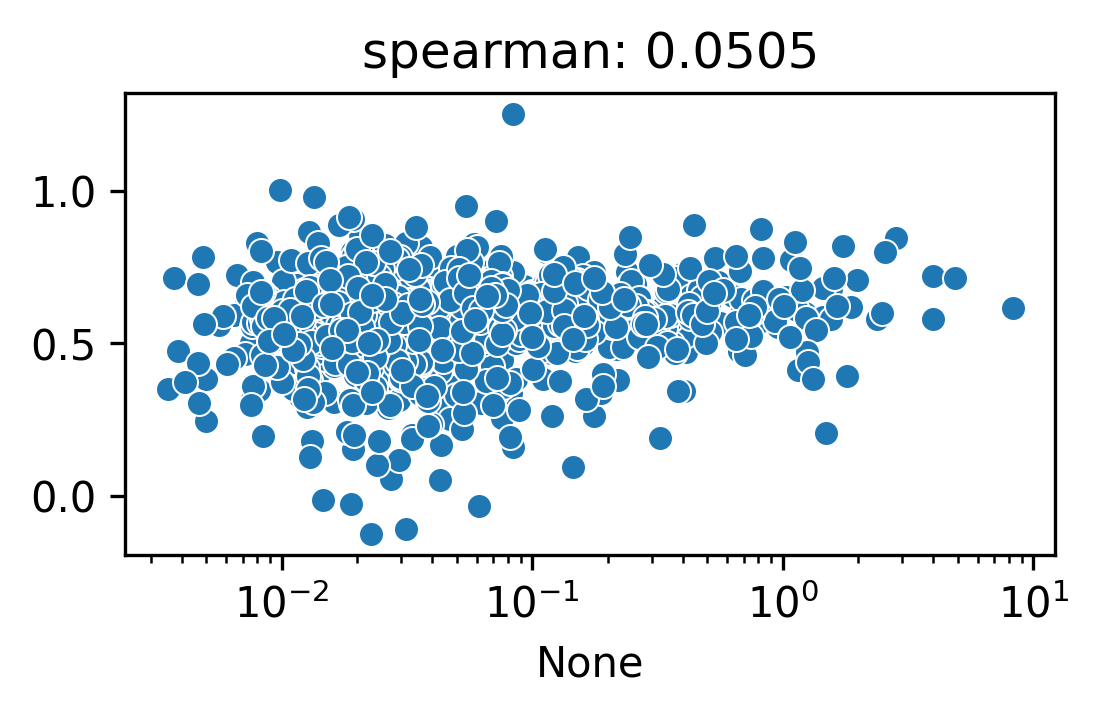

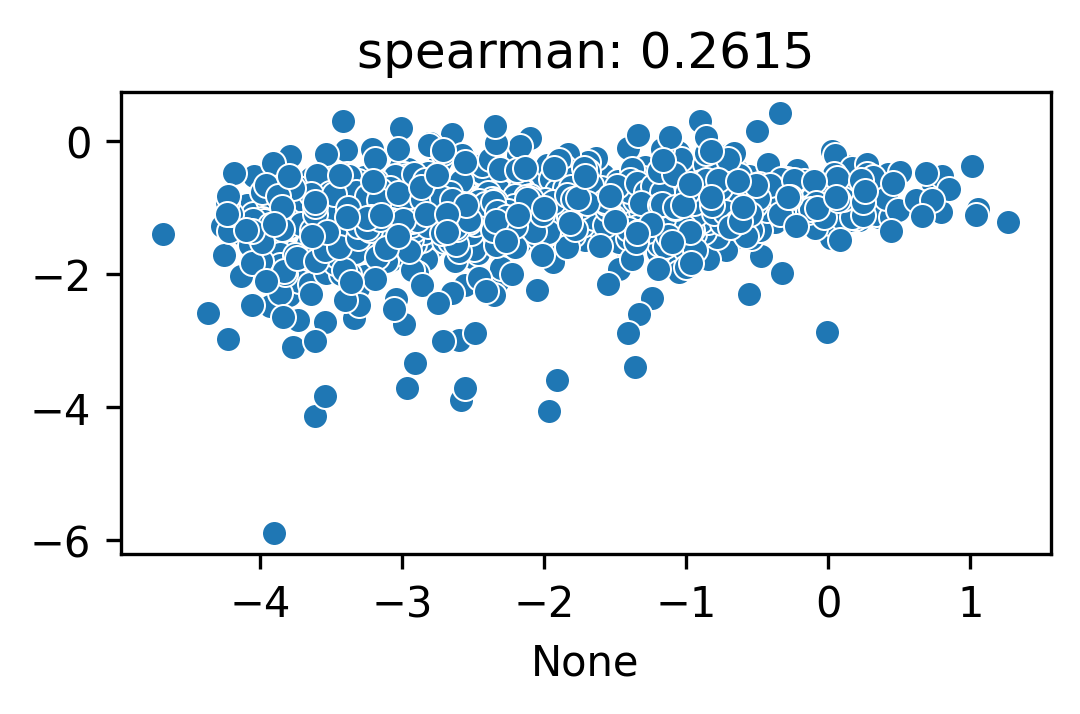

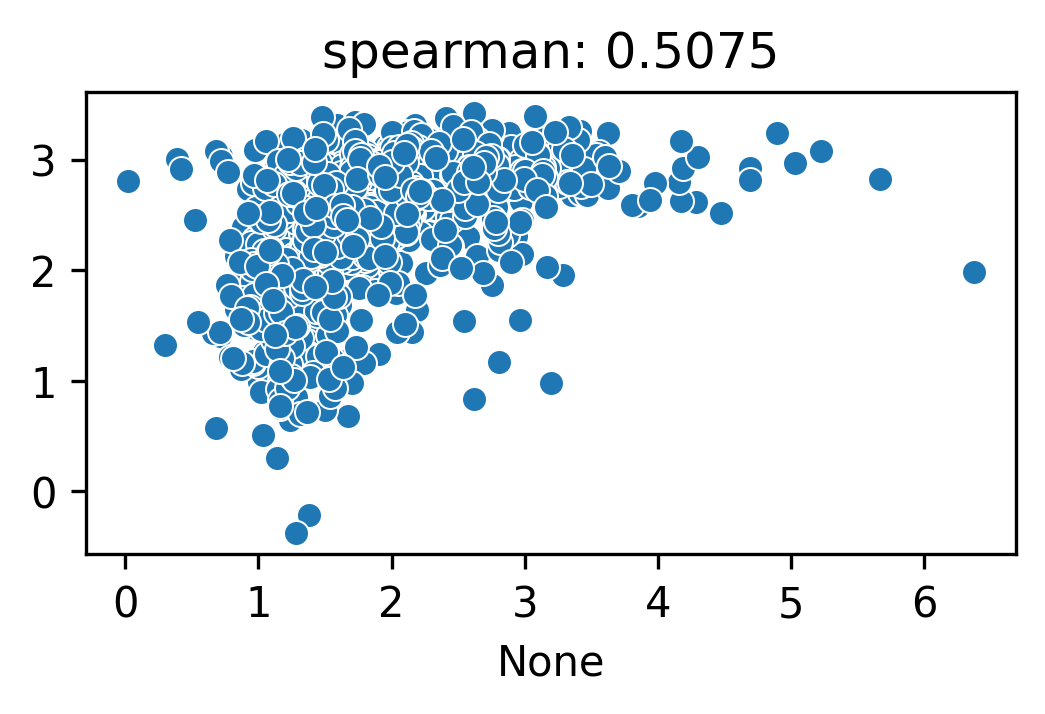

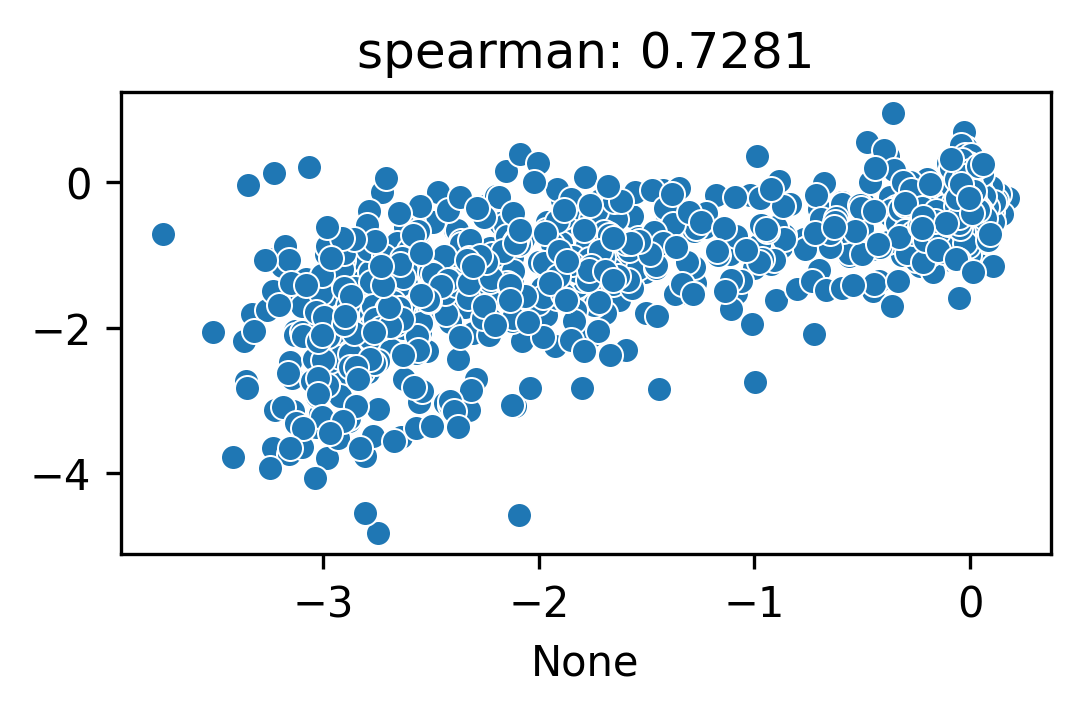

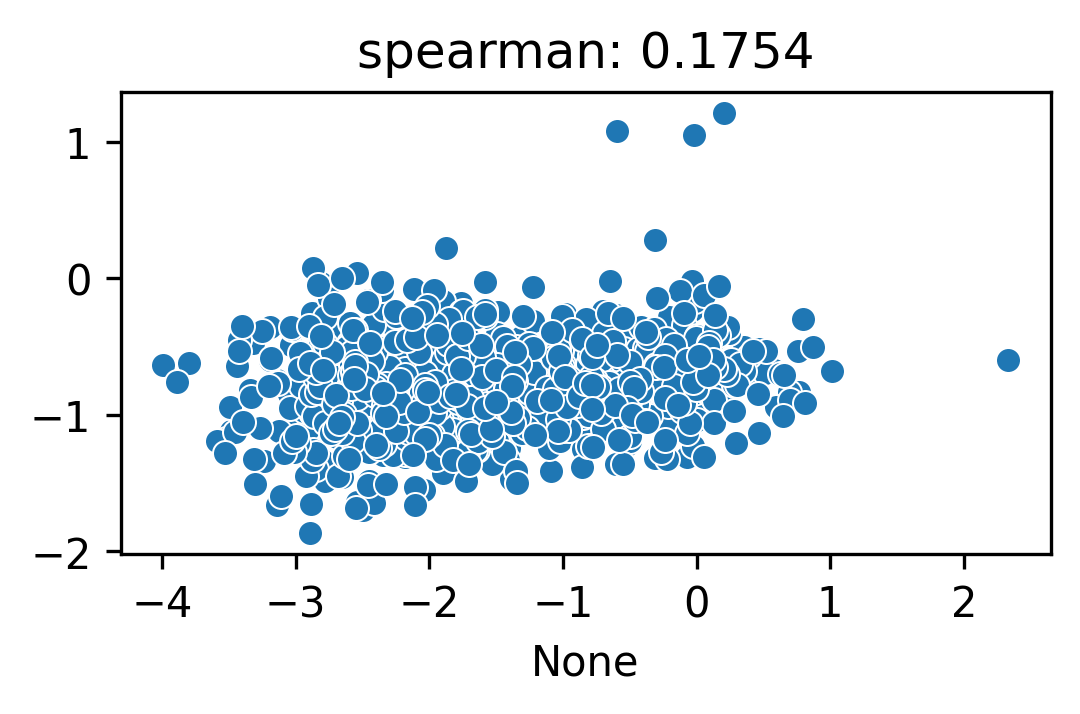

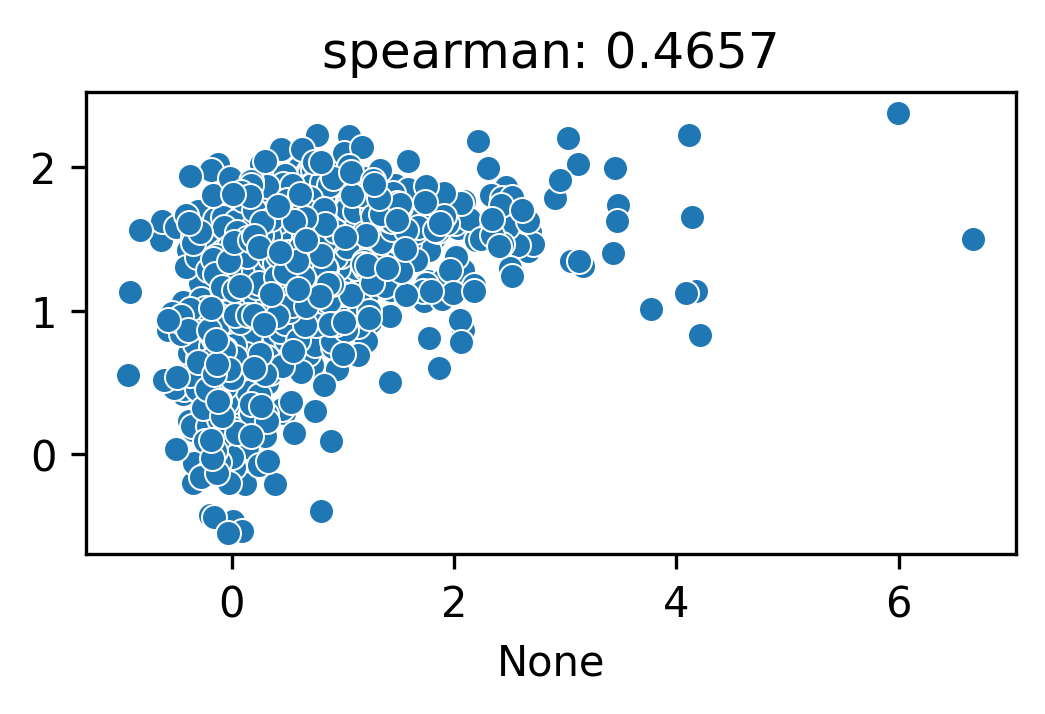

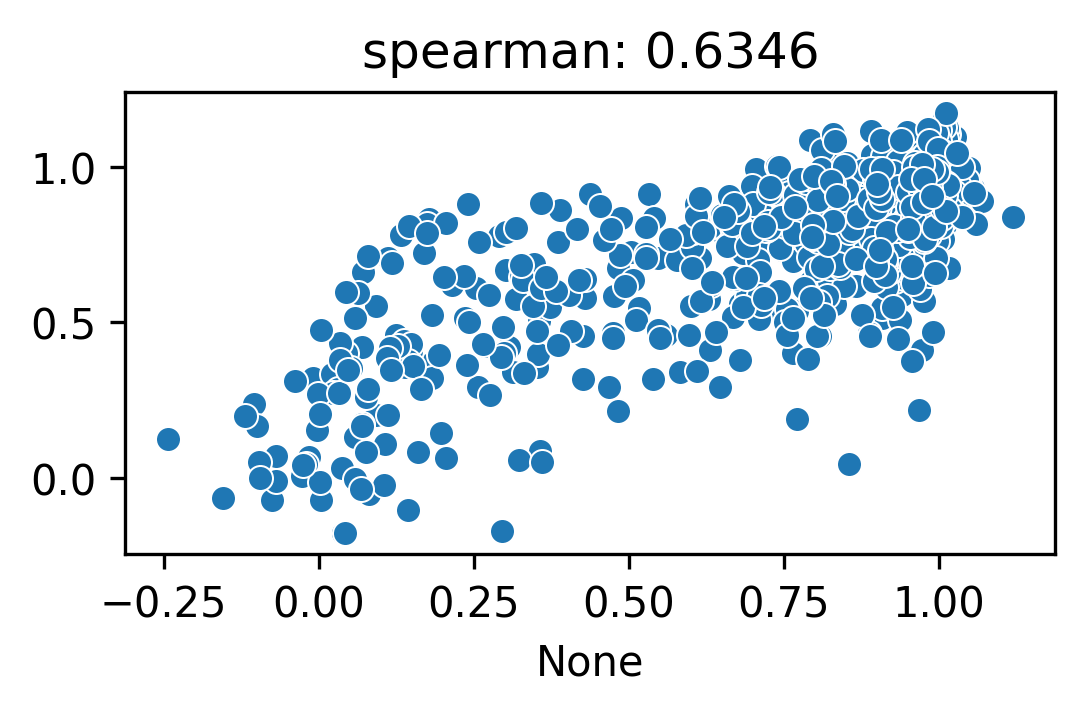

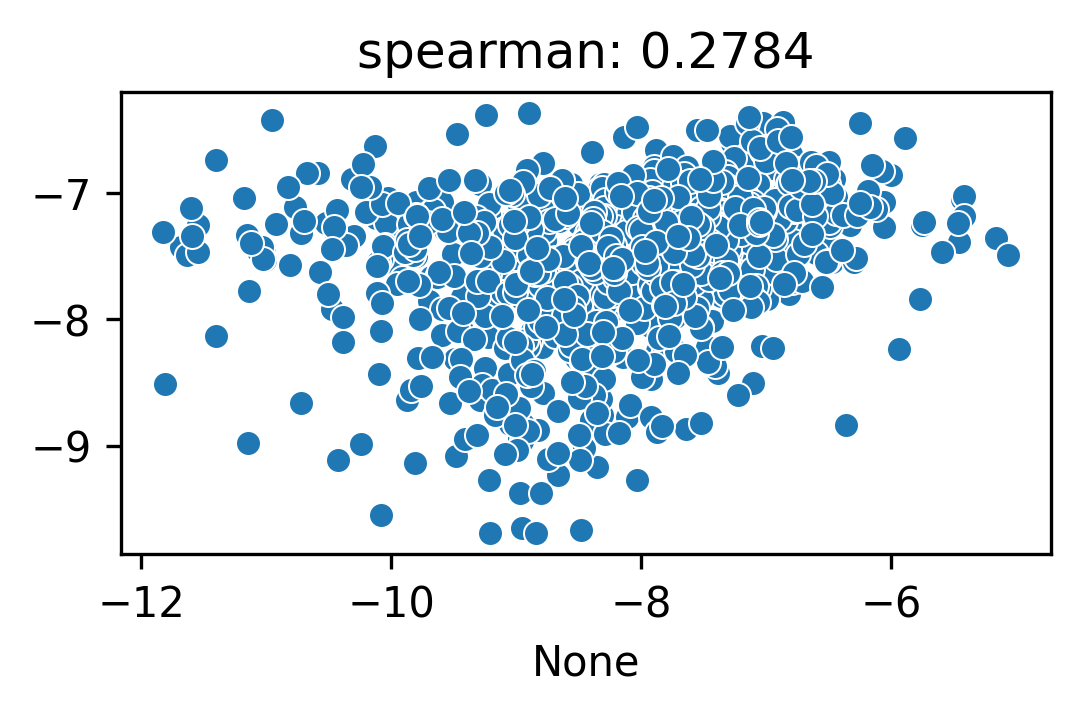

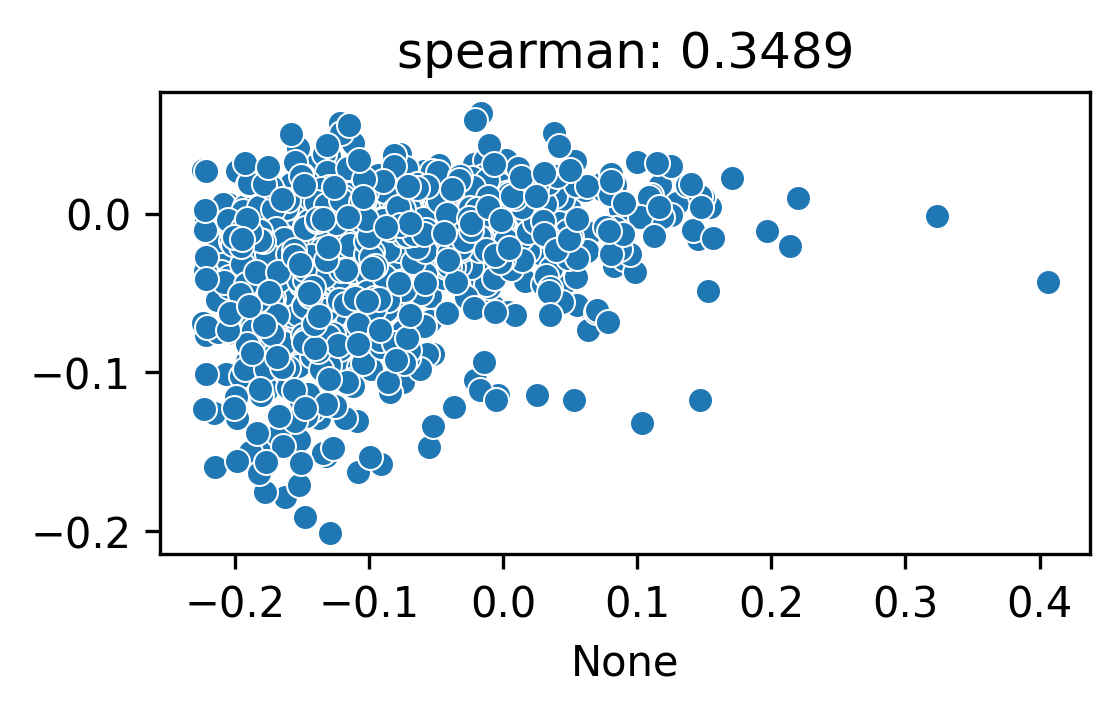

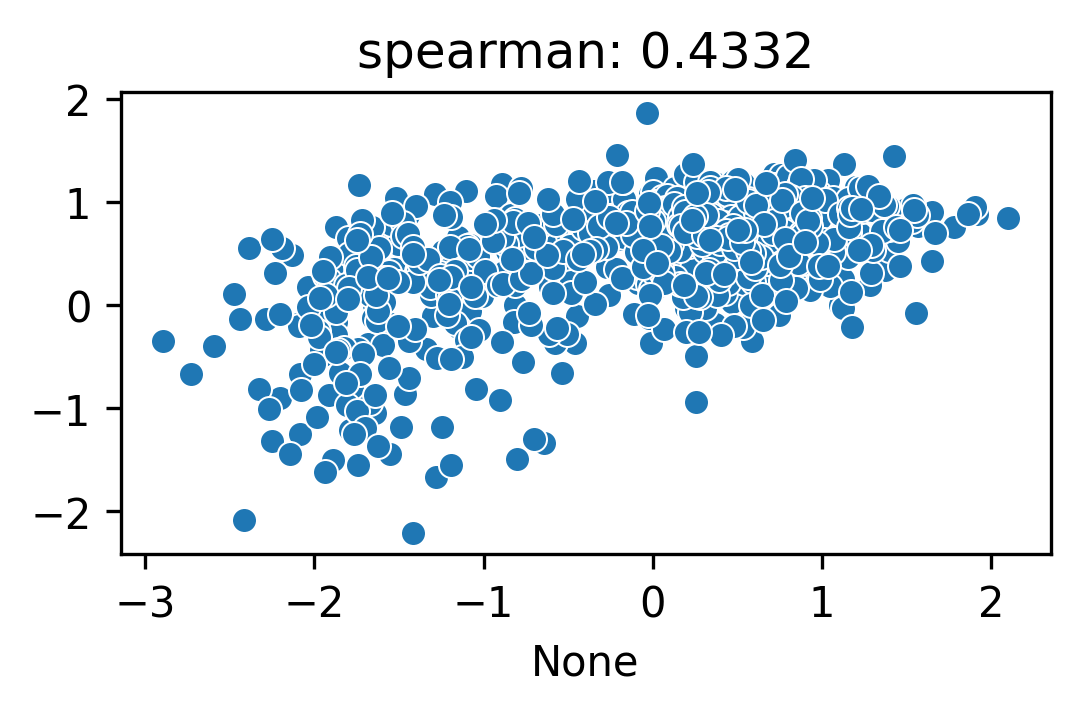

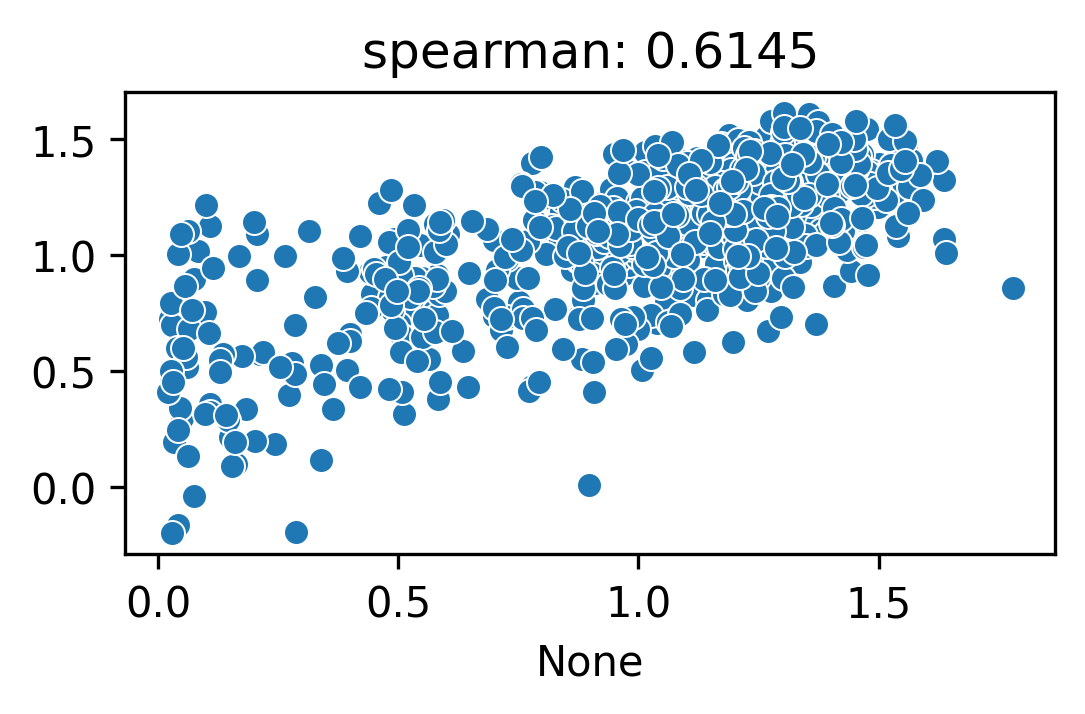

In [82]:
for ii in range(len(val_util_list)):
    plt.figure(figsize=(4,2), dpi=300)
    sns.scatterplot(
        x=batch_constructors[ii].act_val,
        y=val_util_list[ii].cpu().numpy()
    )
    if ii == 0:
        plt.xscale('log')
    spearman = scipy.stats.spearmanr(batch_constructors[ii].act_val, val_util_list[ii].cpu().numpy())[0]
    plt.title(f"spearman: {spearman:.4f}")


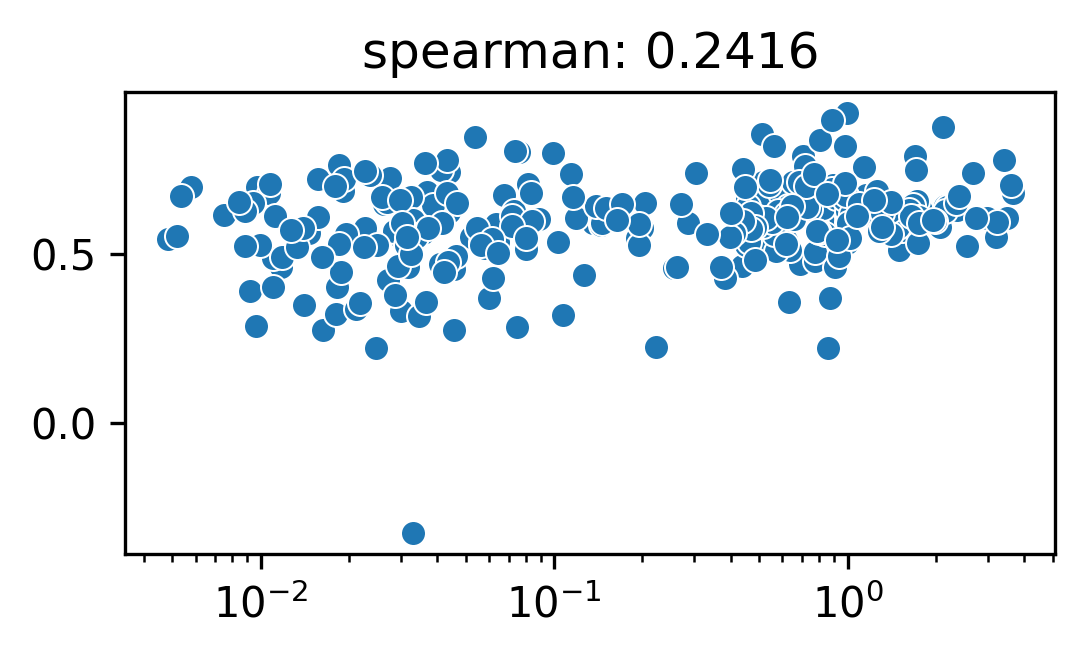

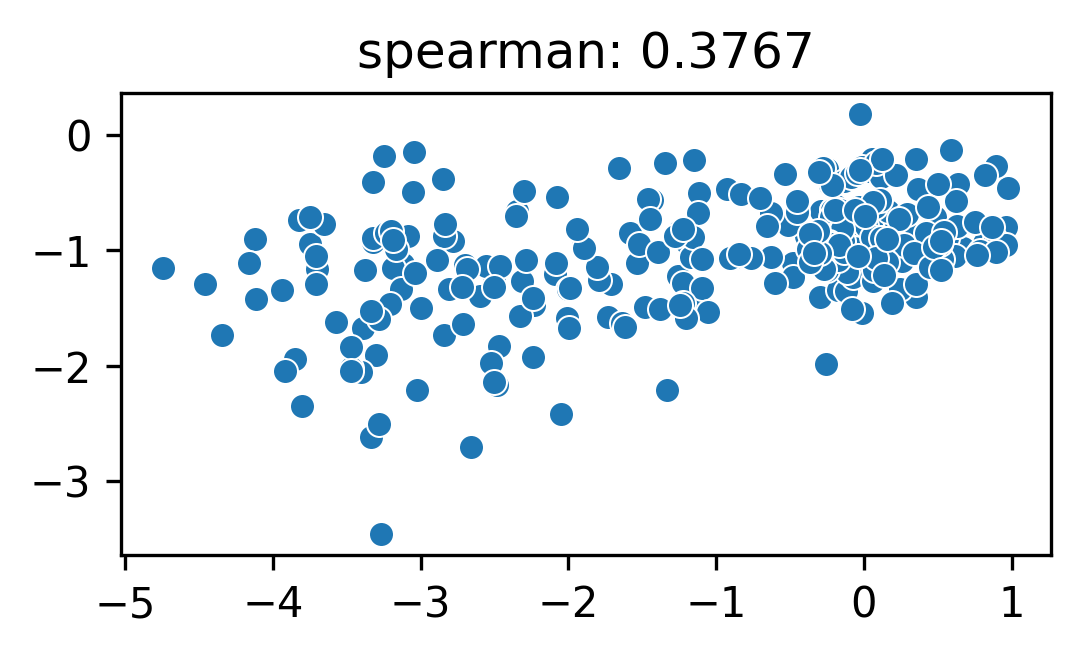

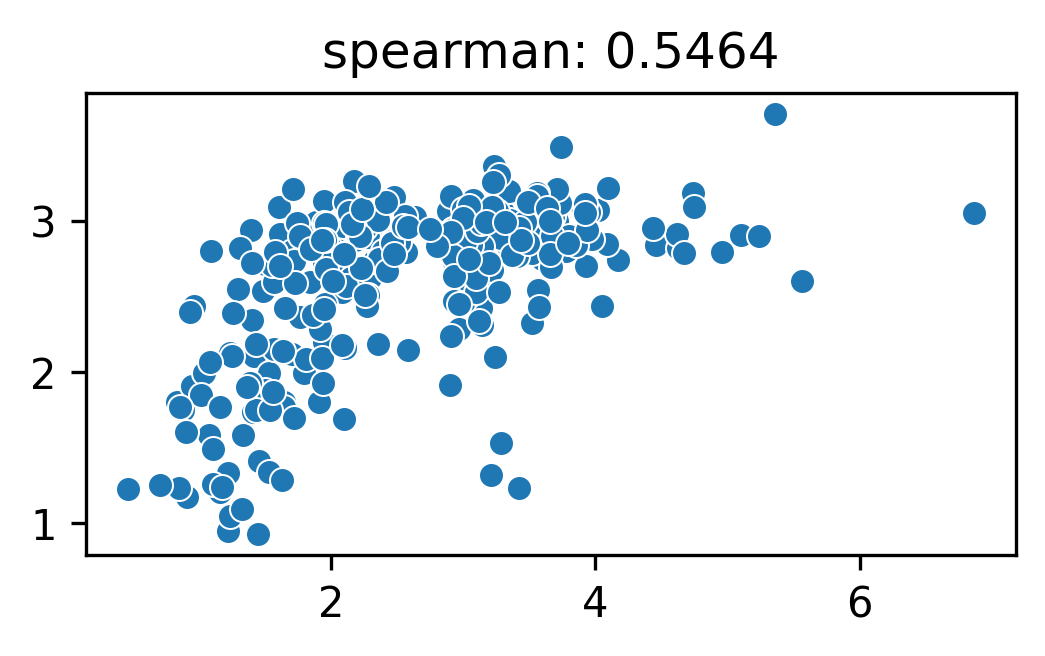

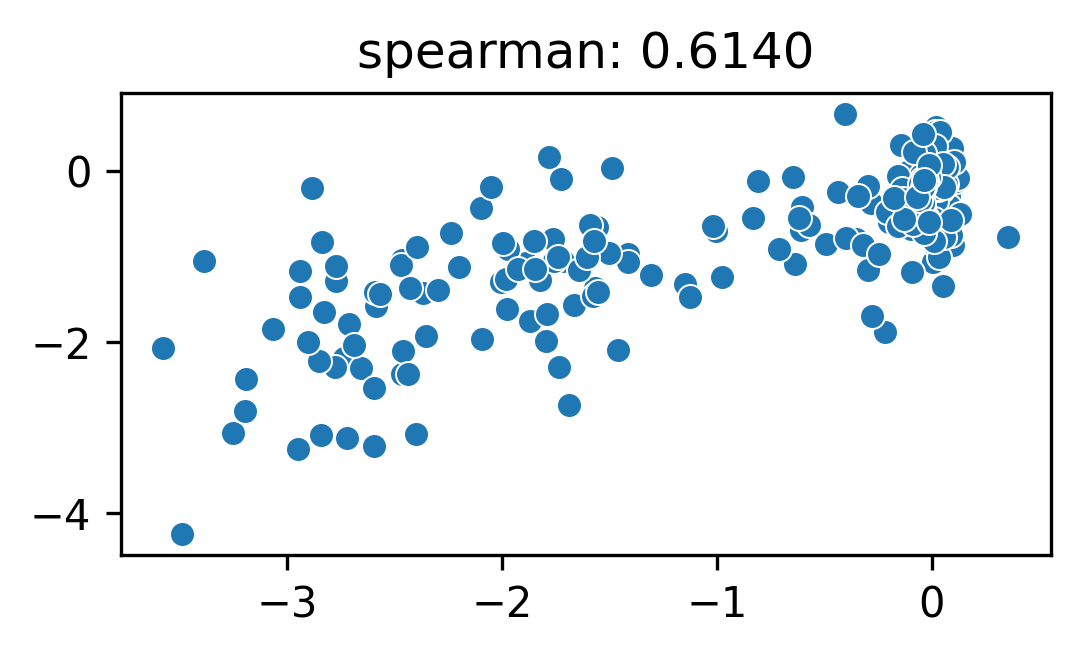

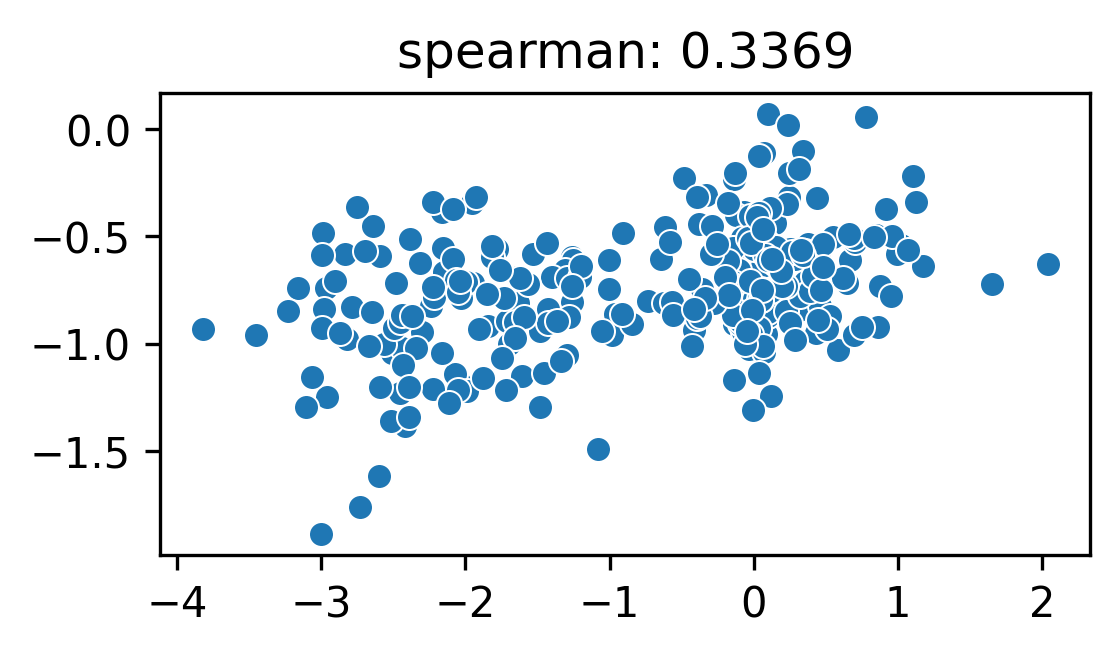

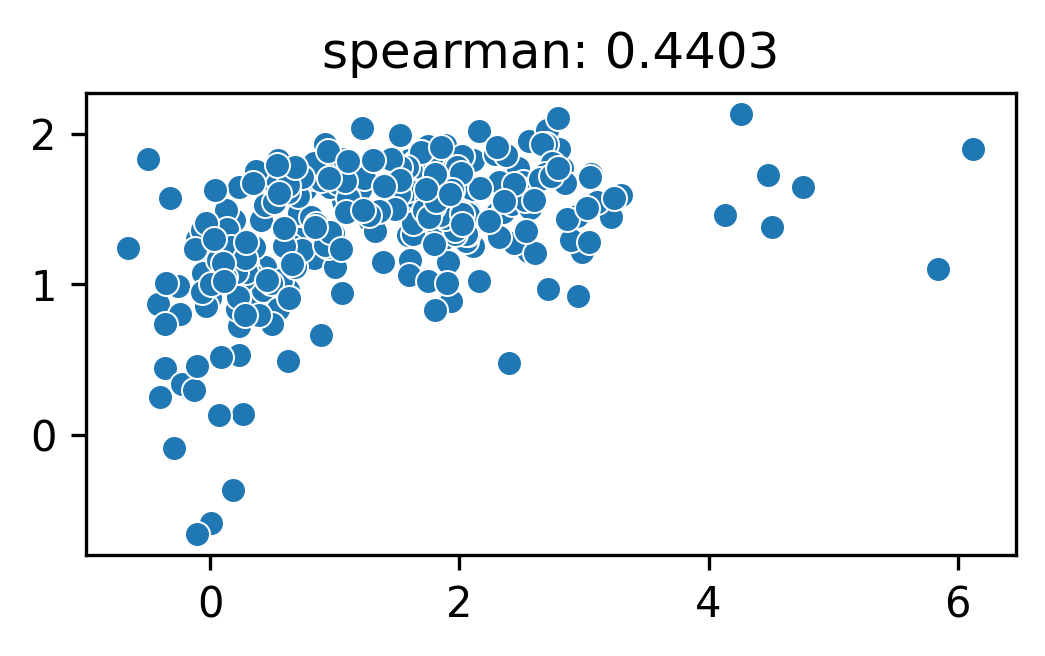

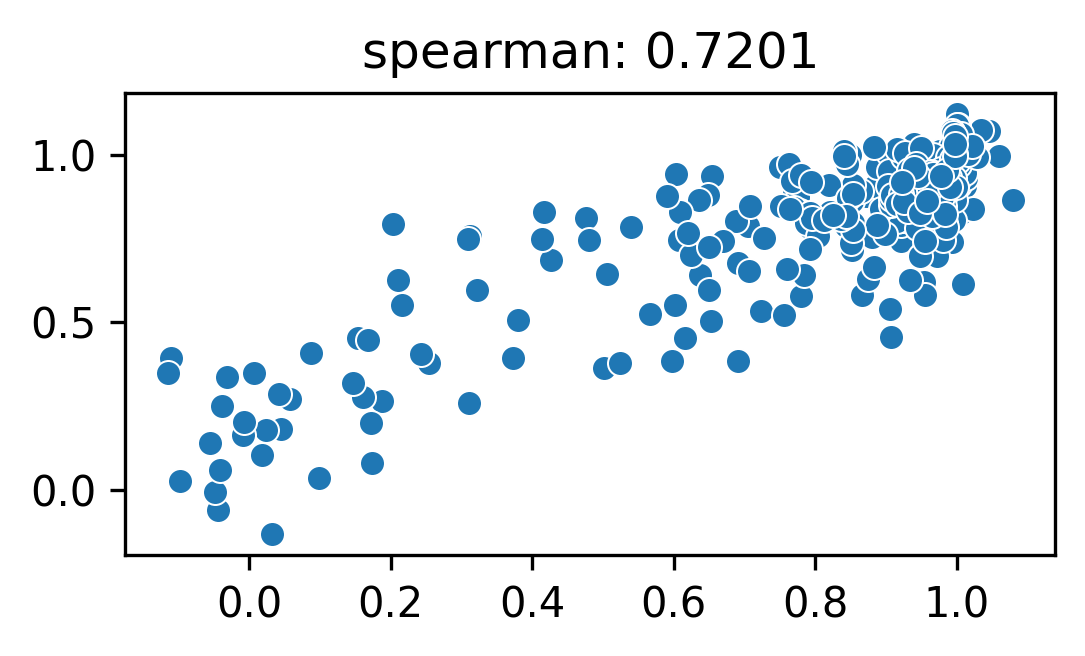

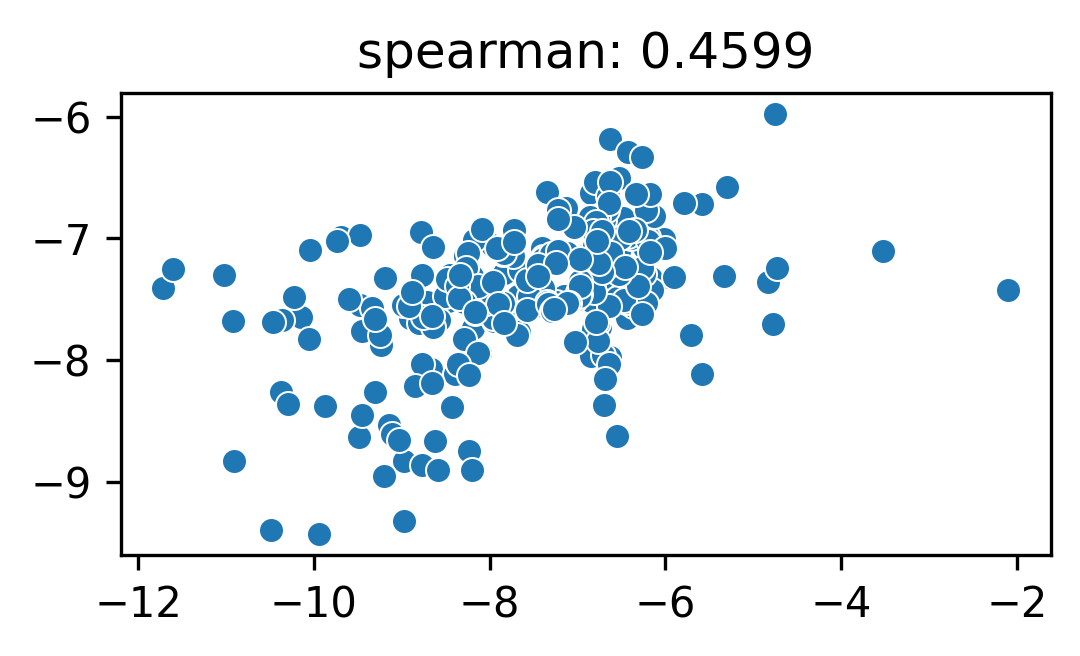

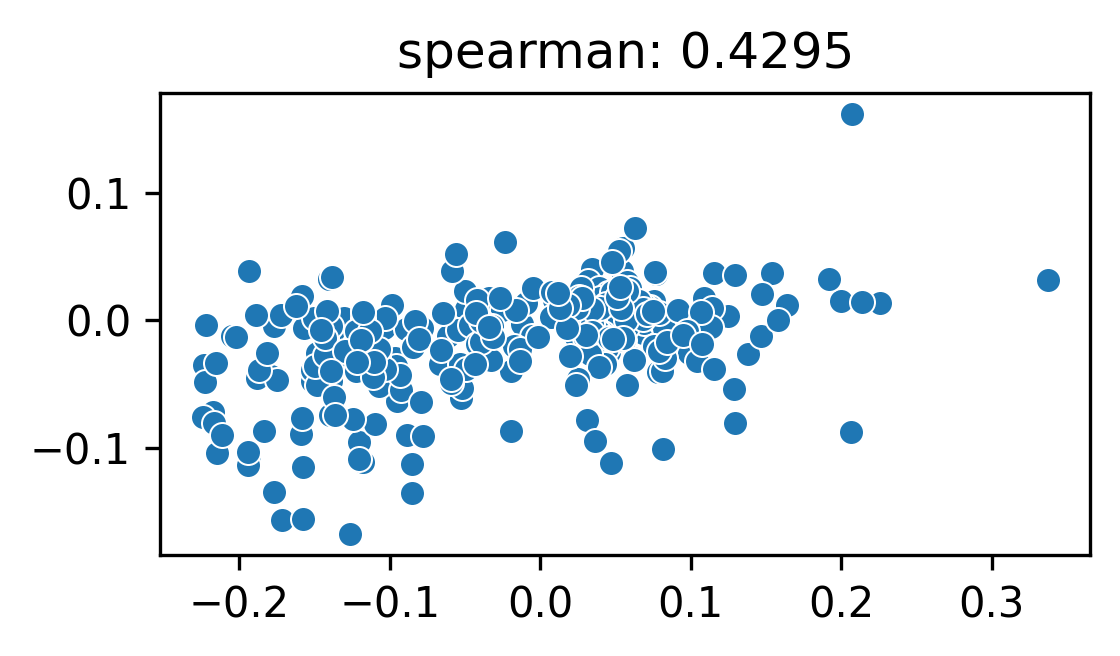

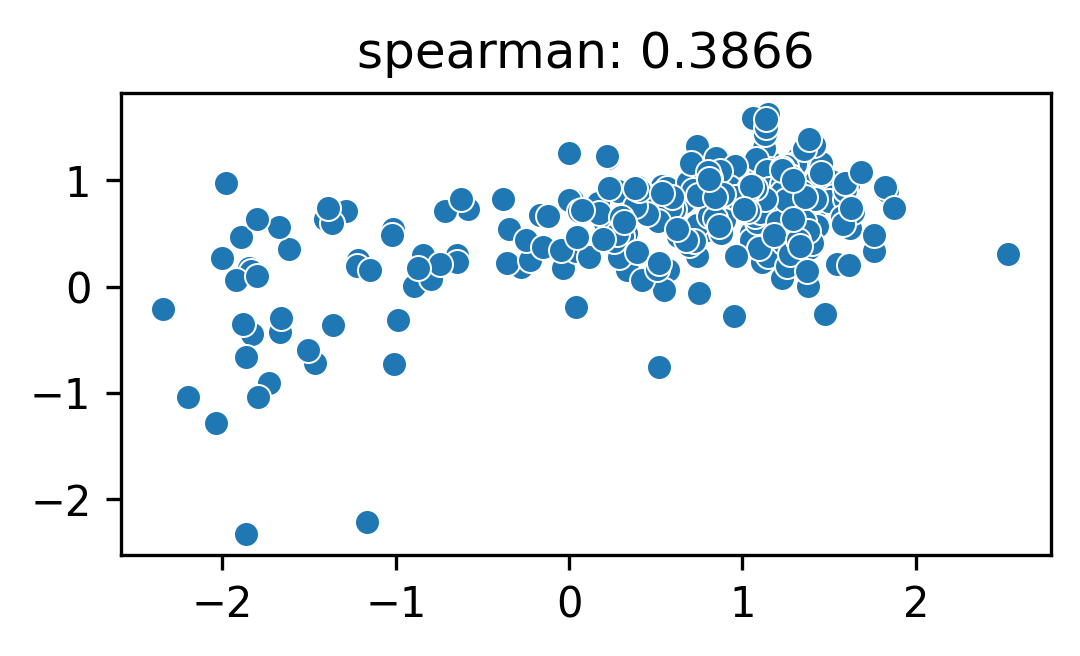

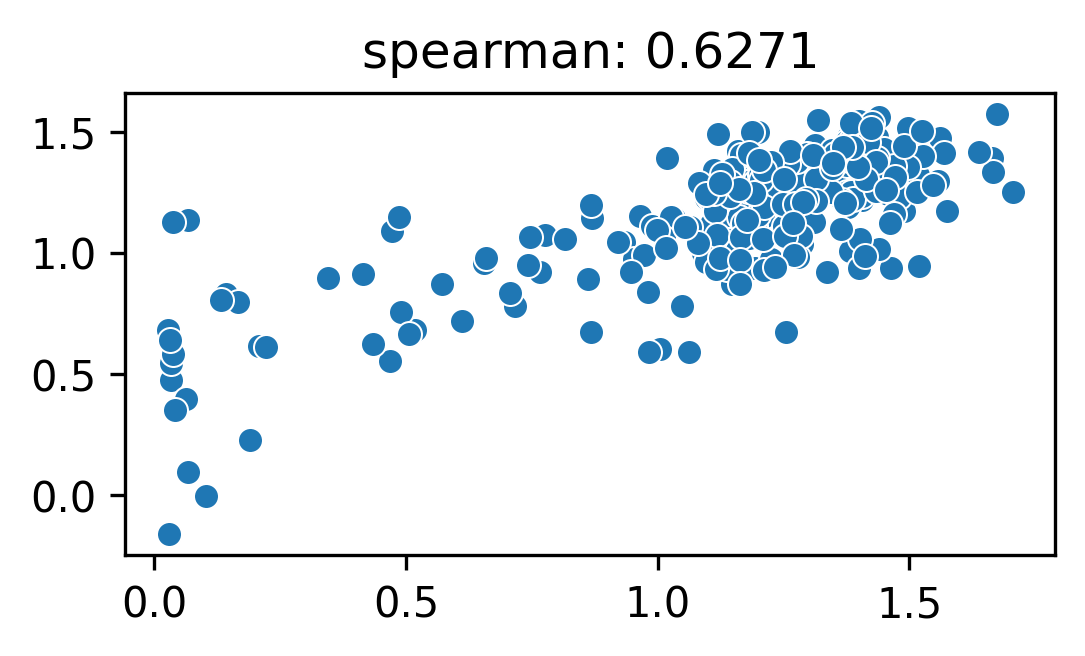

In [83]:
for ii in range(len(train_util_list)):
    plt.figure(figsize=(4,2), dpi=300)
    sns.scatterplot(x=batch_constructors[ii].act_train, y=train_util_list[ii].cpu().numpy())
    if ii == 0:
        plt.xscale('log')
    spearman = scipy.stats.spearmanr(batch_constructors[ii].act_train, train_util_list[ii].cpu().numpy())[0]
    plt.title(f"spearman: {spearman:.4f}")


# Evaluating on other proteins

In [ ]:
# new_ids

util_list = []
for model, bc in zip(models, batch_constructors):
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        emb = bc.emb_train
        nat = bc.nat_train
        X_all = torch.cat([emb, nat.unsqueeze(-1)], dim=-1)
        f_dist = model(X_all)  # Exact posterior (N-dim MVN)
        util = f_dist.mean  # (N,)  
        util_list.append(util)